# EDA - Telco Customer Churn

Esse notebook mostra a análise exploratória inicial do dataset Telco Customer Churn, utilizado no Tech Challenge 01 da Pós Tech FIAP em Machine Learning Engineering.
O objetivo é entender o problema de churn, avaliar a qualidade dos dados e identificar padrões relevantes antes da etapa de modelagem.

## 1. Contexto do problema

Churn representa o cancelamento de clientes.
No contexto de telecomunicações, prever churn é importante porque permite priorizar ações de retenção pra clientes com maior risco de cancelamento.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv").exists():
    PROJECT_ROOT = CURRENT_DIR
else:
    PROJECT_ROOT = CURRENT_DIR.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

print(f"Caminho do dataset: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

df.head()

Caminho do dataset: c:\Users\Dog Bento\Documents\tech-challenge-churn-mlp\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Volume de dados

Nessa etapa, verificamos a quantidade de linhas e colunas da base.

In [5]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 7043
Colunas: 21


## 3. Colunas disponíveis

A seguir, listamos as colunas do dataset.

In [6]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

## 4. Tipos de dados

Aqui verificamos se as colunas estão com os tipos adequados.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 5. Valores ausentes

A coluna `TotalCharges` pode conter valores em branco. Por isso, ela será convertida para numérica na etapa de limpeza.

In [8]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
df["TotalCharges_numeric"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Valores ausentes após conversão de TotalCharges:")
print(df["TotalCharges_numeric"].isna().sum())

Valores ausentes após conversão de TotalCharges:
11


## 6. Distribuição da variável alvo

A variável alvo é `Churn`.
Ela indica se o cliente cancelou ou não o serviço.

In [10]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

pd.DataFrame({
    "quantidade": churn_counts,
    "percentual": churn_percent.round(2)
})

,quantidade,percentual
Churn,,
No,5174,73.46
Yes,1869,26.54


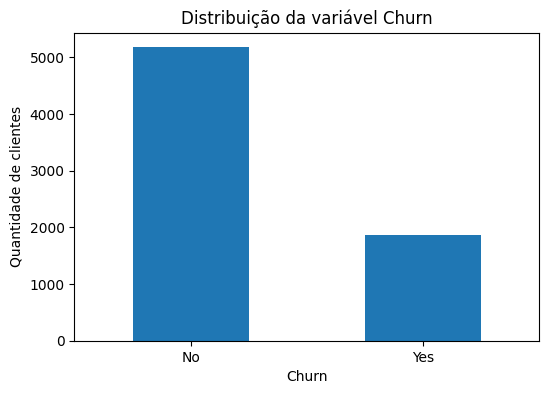

In [11]:
plt.figure(figsize=(6, 4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribuição da variável Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de clientes")
plt.xticks(rotation=0)
plt.show()

## 7. Estatísticas das variáveis numéricas

As principais variáveis numéricas analisadas são:

- `tenure`: tempo como cliente;
- `MonthlyCharges`: cobrança mensal;
- `TotalCharges_numeric`: cobrança total.

In [12]:
numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges_numeric"]
df[numeric_columns].describe()

,tenure,MonthlyCharges,TotalCharges_numeric
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


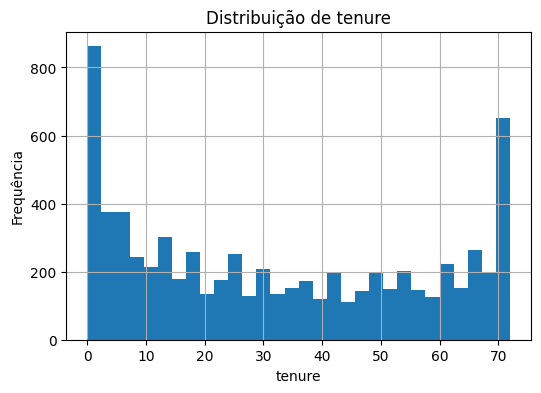

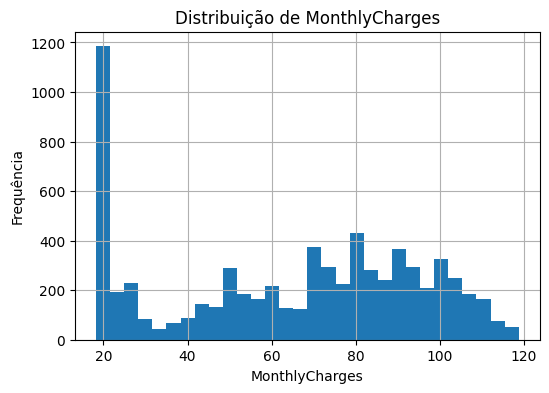

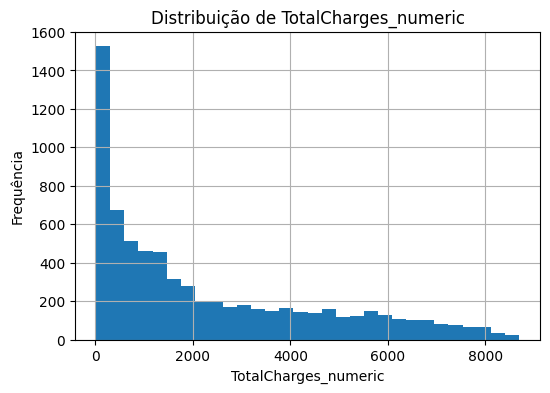

In [13]:
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    df[column].hist(bins=30)
    plt.title(f"Distribuição de {column}")
    plt.xlabel(column)
    plt.ylabel("Frequência")
    plt.show()

## 8. Churn por tipo de contrato

Clientes com contrato mensal tendem a ter menor barreira de saída e podem apresentar maior risco de churn.

In [14]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .rename("percentual")
    .reset_index()
)

contract_churn["percentual"] = (contract_churn["percentual"] * 100).round(2)
contract_churn

,Contract,Churn,percentual
0,Month-to-month,No,57.29
1,Month-to-month,Yes,42.71
2,One year,No,88.73
3,One year,Yes,11.27
4,Two year,No,97.17
5,Two year,Yes,2.83


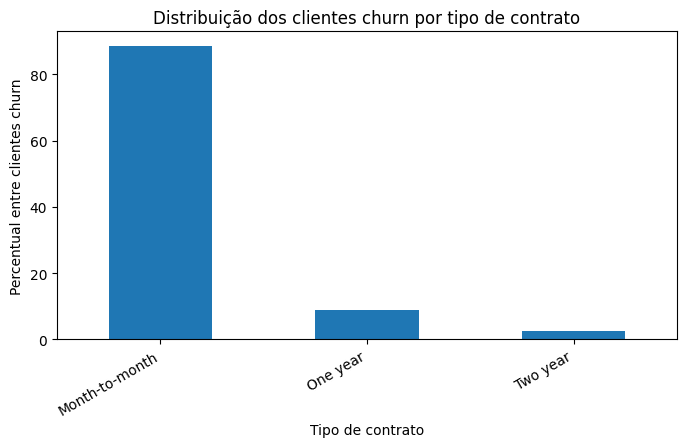

In [15]:
churn_yes_by_contract = (
    df[df["Churn"] == "Yes"]["Contract"]
    .value_counts(normalize=True)
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8, 4))
churn_yes_by_contract.plot(kind="bar")
plt.title("Distribuição dos clientes churn por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Percentual entre clientes churn")
plt.xticks(rotation=30, ha="right")
plt.show()

## 9. Churn por método de pagamento

O método de pagamento pode indicar padrões comportamentais associados ao cancelamento.

In [16]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .value_counts(normalize=True)
    .rename("percentual")
    .reset_index()
)

payment_churn["percentual"] = (payment_churn["percentual"] * 100).round(2)
payment_churn

,PaymentMethod,Churn,percentual
0,Bank transfer (automatic),No,83.29
1,Bank transfer (automatic),Yes,16.71
2,Credit card (automatic),No,84.76
3,Credit card (automatic),Yes,15.24
4,Electronic check,No,54.71
5,Electronic check,Yes,45.29
6,Mailed check,No,80.89
7,Mailed check,Yes,19.11


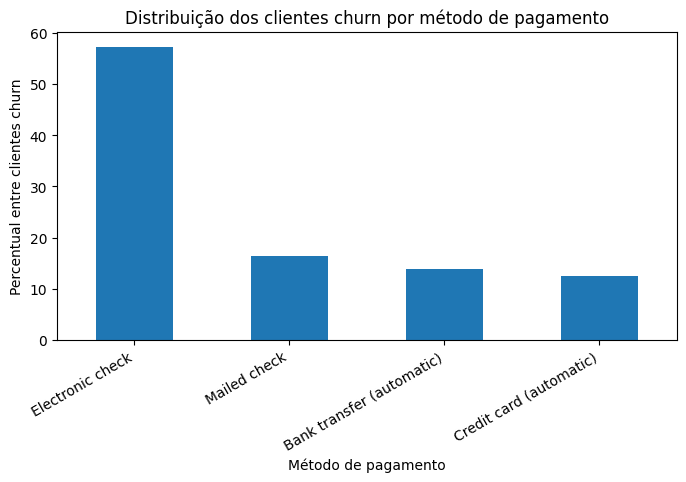

In [17]:
churn_yes_by_payment = (
    df[df["Churn"] == "Yes"]["PaymentMethod"]
    .value_counts(normalize=True)
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8, 4))
churn_yes_by_payment.plot(kind="bar")
plt.title("Distribuição dos clientes churn por método de pagamento")
plt.xlabel("Método de pagamento")
plt.ylabel("Percentual entre clientes churn")
plt.xticks(rotation=30, ha="right")
plt.show()

## 10. Principais conclusões da EDA

A análise exploratória indica que:

1. O dataset possui mais de 5.000 registros e mais de 10 features, atendendo ao requisito do desafio.
2. A variável alvo `Churn` é binária, caracterizando um problema de classificação supervisionada.
3. A classe de churn é menor que a classe de não churn, por isso métricas como ROC-AUC, PR-AUC, Recall e F1 são importantes.
4. A coluna `TotalCharges` precisa de conversão para formato numérico.
5. Variáveis como tipo de contrato, método de pagamento, tempo como cliente e cobranças podem ter relação relevante com churn.
6. O dataset está adequado para construção de baselines e da MLP em PyTorch.